In [1]:
#!pip install implicit --upgrade

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.3/70.3 kB 2.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for implicit: filename=implicit-0.7.2-cp312-cp312-linux_x86_64.whl size=933264 sha256=5506cf9fc657bc646828aad16e725ed4196f53cac1e8689ff58e84b2f08349de
  Stored in directory: /root/.cache/pip/wheels/b2/00/4f/9ff8af07a0a53ac6007ea5d739da19cfe147a2df542b6899f8
Successfully built implicit


In [2]:
import implicit
import itertools
import numpy as np
import pandas as pd
import scipy.sparse as sparse
import matplotlib.pyplot as plt
from collections import namedtuple

In [3]:
# Lectura de datos de entrenamiento y validación
wk_train = pd.read_csv("wikimedia_train.csv")
wk_val = pd.read_csv("wikimedia_validation.csv")

In [4]:
# Transformamos la columna booleana en int (binario)
wk_train["evaluation"] = wk_train["evaluation"].astype(int)
wk_val["evaluation"] = wk_val["evaluation"].astype(int)

In [5]:
user_items_val = {}

for row in wk_val.itertuples():
    if row[1] not in user_items_val:
        user_items_val[row[1]] = []

    user_items_val[row[1]].append(row[2])

### Análisis exploratorio

In [6]:
# Resumen del dataset de entrenamiento
wk_train.describe()

,user_id,item_id,timestamp,evaluation
count,67806.000000,6.780600e+04,6.780600e+04,67806.000000
mean,3467.234183,2.012982e+08,1.369731e+09,0.000118
std,2047.236999,3.519299e+05,1.113170e+08,0.010861
min,1.000000,2.005010e+08,1.105491e+09,0.000000
25%,1706.000000,2.010081e+08,1.282098e+09,0.000000
50%,3714.000000,2.014022e+08,1.392957e+09,0.000000
75%,5049.000000,2.016031e+08,1.457634e+09,0.000000
max,7395.000000,2.019042e+08,1.556020e+09,1.000000


In [7]:
pd.DataFrame(data={
  "Statistic": [
    "Number of Users",
    "Number of Items",
    "Total Ratings",
    "Average Number of Ratings per User",
    "Average Number of Ratings per Item",
    "Highest Number of Ratings by a User",
    "Highest Number of Ratings for an Item",
    "Density"],
  "Training": [
    len(wk_train.drop_duplicates("user_id")),
    len(wk_train.drop_duplicates("item_id")),
    len(wk_train[wk_train["evaluation"] == 1]),
    wk_train[wk_train["evaluation"] == 1].groupby("user_id")["evaluation"].sum().mean(),
    wk_train[wk_train["evaluation"] == 1].groupby("item_id")["evaluation"].sum().mean(),
    wk_train[wk_train["evaluation"] == 1].groupby("user_id")["evaluation"].sum().max(),
    wk_train[wk_train["evaluation"] == 1].groupby("item_id")["evaluation"].sum().max(),
    0],
  "Validation": [
    len(wk_val.drop_duplicates("user_id")),
    len(wk_val.drop_duplicates("item_id")),
    len(wk_val[wk_val["evaluation"] == 1]),
    wk_val[wk_val["evaluation"] == 1].groupby("user_id")["evaluation"].sum().mean(),
    wk_val[wk_val["evaluation"] == 1].groupby("item_id")["evaluation"].sum().mean(),
    wk_val[wk_val["evaluation"] == 1].groupby("user_id")["evaluation"].sum().max(),
    wk_val[wk_val["evaluation"] == 1].groupby("item_id")["evaluation"].sum().max(),
    0]})

,Statistic,Training,Validation
0,Number of Users,1079.000000,1075.0
1,Number of Items,9526.000000,5473.0
2,Total Ratings,8.000000,11.0
3,Average Number of Ratings per User,1.000000,1.0
4,Average Number of Ratings per Item,1.142857,1.0
5,Highest Number of Ratings by a User,1.000000,1.0
6,Highest Number of Ratings for an Item,2.000000,1.0
7,Density,0.000000,0.0


In [8]:
wk_train

,user_id,item_id,timestamp,evaluation
0,1,200502005,1108503300,0
1,1,200504028,1113243060,0
2,1,200504029,1113243060,0
3,1,200504034,1113246480,0
4,1,200504035,1113246600,0
...,...,...,...,...
67801,7395,201904158,1555263120,0
67802,7395,201904173,1555317600,0
67803,7395,201904201,1555897200,0
67804,7395,201904228,1556006940,0


### Métricas

In [9]:
# Definicion de métricas. Código extraído de práctico 3
def precision_at_k(r, k):
    assert 1 <= k <= r.size
    return (np.asarray(r)[:k]).mean()

def recall_at_k(r, k):
    assert 1 <= k <= r.size
    return (np.asarray(r)[:k]).sum() / np.asarray(r).sum()

def average_precision_at_k(r, k):
    r = np.asarray(r)
    n_rel = r.sum() # Número de items relevantes
    if n_rel == 0:
        return 0.
    vectorized_precision = np.vectorize(lambda i: precision_at_k(r, i))
    indices = np.arange(1, len(r) + 1)
    precisions = vectorized_precision(indices) # Precision@k por cada posición del ranking
    score = np.sum(precisions * r)
    return score / min(k, n_rel)

def dcg_at_k(r, k):
    r = np.asarray(r)[:k]
    if r.size:
        return np.sum(np.subtract(np.power(2, r), 1) / np.log2(np.arange(2, r.size + 2)))
    return 0.


def ndcg_at_k(r, k):
    idcg = dcg_at_k(sorted(r, reverse=True), k)

    if not idcg:
        return 0.
    return dcg_at_k(r, k) / idcg

### Preprocesamiento de los datos a formato sparse

In [10]:
# Código extraído de práctico 3
user_items = {}
itemset = set()

for row in wk_train.itertuples():
    if row[1] not in user_items:
        user_items[row[1]] = []

    user_items[row[1]].append(row[2])
    itemset.add(row[2])

itemset = np.sort(list(itemset))

sparse_matrix = np.zeros((len(user_items), len(itemset)))

for i, items in enumerate(user_items.values()):
    sparse_matrix[i] = np.isin(itemset, items, assume_unique=True).astype(int)

matrix = sparse.csr_matrix(sparse_matrix.T)

user_item_matrix = matrix.T.tocsr()

In [11]:
# Mapeo de user id a fila de la matriz sparse. Código extraído de práctico 3
user2row = {user_id: matrix_row for matrix_row, user_id in enumerate(user_items.keys())}
row2user = {matrix_row: user_id for user_id, matrix_row in user2row.items()}

# Mapeo de item id a columna de la matriz sparse. Código extraído de práctico 3
item2col = {item_id: matrix_col for matrix_col, item_id in enumerate(itemset)}
col2item = {matrix_col: item_id for item_id, matrix_col in item2col.items()}

In [12]:
# Función para evaluar un modelo a partir de las métricas ya definididas. Código extraído de práctico 3
def evaluate_model(model, n):
  mean_ap = 0. # o MAP
  mean_ndcg = 0.
  for user_id in user_items_val.keys():
    user_row = user2row[user_id]
    rec = model.recommend(user_row, user_item_matrix[user_row], n)[0]
    rec = [col2item[col] for col in rec]
    rel_vector = np.isin(rec, user_items_val[user_id], assume_unique=True).astype(int)
    mean_ap += average_precision_at_k(rel_vector, n)
    mean_ndcg += ndcg_at_k(rel_vector, n)

  mean_ap /= len(user_items_val)
  mean_ndcg /= len(user_items_val)

  return mean_ap, mean_ndcg

### ALS

In [13]:
# Cantidad de factores latentes
factors = [10, 50, 100, 150, 200]
# Factor de regularización
regs = [0.01, 0.05, 0.15, 0.35]

# Definimos una tupla para almacenar las métricas
Metrics = namedtuple("Metrics",["map", "ndcg"] )

models_perf = {}

# Entrenamos el modelo con optimización ALS para cada combinación de parametros
for factor, reg in itertools.product(factors, regs):
  model_als = implicit.als.AlternatingLeastSquares(factors=factor, regularization=reg, iterations=15, use_gpu=False)
  model_als.fit(user_item_matrix)

  # Evaluamos el modelo con k=10
  mean_ap, mean_ndcg = evaluate_model(model_als, 10)
  models_perf[(factor, reg)] = Metrics(mean_ap, mean_ndcg)


/usr/local/lib/python3.12/dist-packages/implicit/cpu/als.py:95: RuntimeWarning: OpenBLAS is configured to use 2 threads. It is highly recommended to disable its internal threadpool by setting the environment variable 'OPENBLAS_NUM_THREADS=1' or by calling 'threadpoolctl.threadpool_limits(1, "blas")'. Having OpenBLAS use a threadpool can lead to severe performance issues here.
  check_blas_config()


  0%|          | 0/15 [00:00<?, ?it/s]

  0%|          | 0/15 [00:00<?, ?it/s]

  0%|          | 0/15 [00:00<?, ?it/s]

  0%|          | 0/15 [00:00<?, ?it/s]

...

  0%|          | 0/15 [00:00<?, ?it/s]

  0%|          | 0/15 [00:00<?, ?it/s]

  0%|          | 0/15 [00:00<?, ?it/s]

  0%|          | 0/15 [00:00<?, ?it/s]

  0%|          | 0/15 [00:00<?, ?it/s]

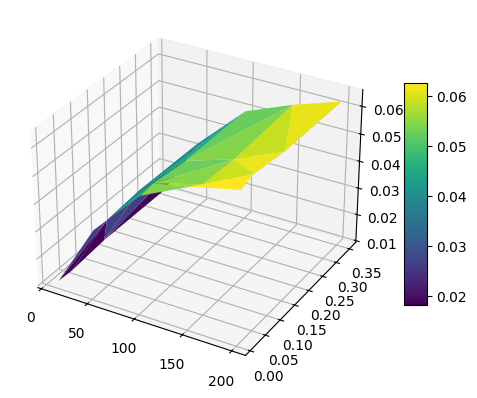

In [14]:
fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
# Gráfico para evolución del MAP de acuerdo a cambios en los factores latentes y factor de regularizaci[ón]
surf = ax.plot_trisurf([p[0] for p in models_perf.keys()], [p[1] for p in models_perf.keys()], [m.map for m in models_perf.values()], cmap="viridis")
fig.colorbar(surf, shrink=0.6, aspect=10)
plt.show()

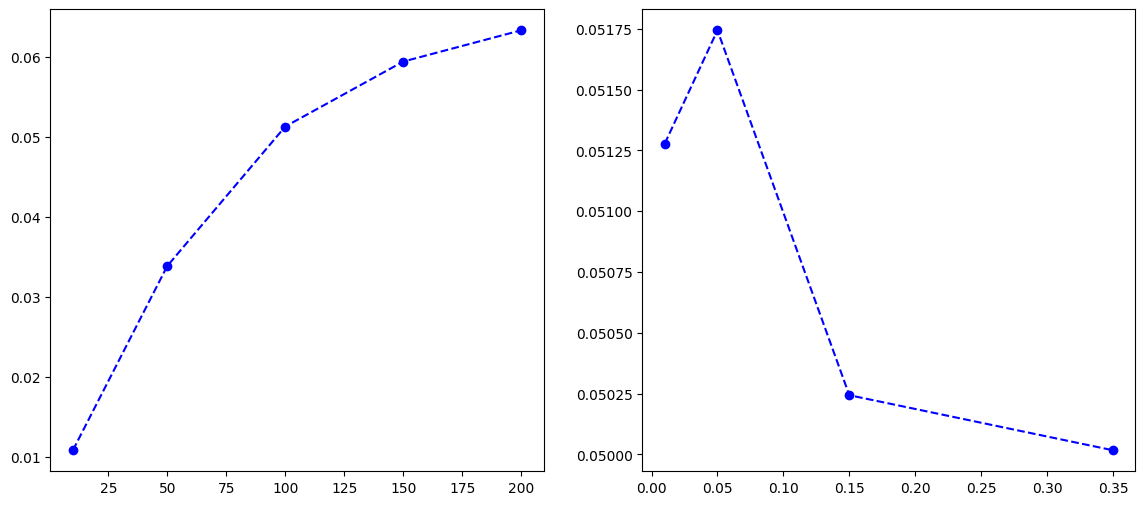

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Graficamos el MAP a partir de la cantidad de factores latentes con factor de regularización fijo en 0.01
axes[0].plot([key[0] for key in models_perf.keys() if key[1] == 0.01], [models_perf[key].map for key in models_perf.keys() if key[1] == 0.01], "--bo")
# Graficamos el MAP a partir del factor de regularización con 100 factores latentes
axes[1].plot([key[1] for key in models_perf.keys() if key[0] == 100], [models_perf[key].map for key in models_perf.keys() if key[0] == 100], "--bo")

In [16]:
maprec, ndcg = evaluate_model(model_als, n=10)
print('map: {}\nndcg: {}'.format(maprec, ndcg))



map: 0.062677150239941
ndcg: 0.08425422685093316
